In [1]:
import openrouteservice
import folium

# ORS 初始化（請填入你的金鑰）
client = openrouteservice.Client(key='5b3ce3597851110001cf624833dd6c06156e46888a0ff84ee6e7df1c')

# 起點（福田水資源回收中心）與新的終點（塑膠中心）
start = (120.6598, 24.1073)
end = (120.5878, 24.1711)  # ✅ 新終點

# 取得路徑
route = client.directions(
    coordinates=[start, end],
    profile='driving-car',
    format='geojson'
)

# 顯示地圖
m = folium.Map(location=[(start[1]+end[1])/2, (start[0]+end[0])/2], zoom_start=14)
folium.GeoJson(route, name='route').add_to(m)
folium.Marker(location=start[::-1], popup='起點：A', icon=folium.Icon(color="green")).add_to(m)
folium.Marker(location=end[::-1], popup='終點：B', icon=folium.Icon(color="red")).add_to(m)
m


In [2]:
import openrouteservice
import folium
import pandas as pd
import json
import random
from datetime import datetime, timedelta

# ORS API 初始化
client = openrouteservice.Client(key='5b3ce3597851110001cf624833dd6c06156e46888a0ff84ee6e7df1c')

# 起訖點設定（起點：福田，終點：塑膠中心）
start = (120.6598, 24.1073)
end = (120.5878, 24.1711)

# 取得路徑（GeoJSON）
route = client.directions(
    coordinates=[start, end],
    profile='driving-car',
    format='geojson'
)

# 擷取所有路段
segments = route['features'][0]['geometry']['coordinates']
segment_info = []
date = datetime(2025, 4, 23)
time_range = [date + timedelta(hours=i) for i in range(24)]
peak_hours = list(range(7, 9)) + list(range(17, 19))

# 模擬每段每小時車速/流量
for idx, segment in enumerate(segments):
    for t in time_range:
        hour = t.hour
        speed = random.randint(5, 15) if hour in peak_hours else random.randint(20, 40)
        volume = random.randint(300, 600) if hour in peak_hours else random.randint(100, 300)
        segment_info.append({
            'segment_id': idx,
            'timestamp': t,
            'speed': speed,
            'volume': volume,
            'segment_coords': json.dumps(segment)
        })

df = pd.DataFrame(segment_info)
df.to_csv("simulated_traffic_data.csv", index=False)


In [3]:
import folium
from folium.plugins import TimestampedGeoJson

m = folium.Map(location=[(start[1]+end[1])/2, (start[0]+end[0])/2], zoom_start=14)

# 標記起點與終點
folium.Marker(start[::-1], popup='起點', icon=folium.Icon(color="green")).add_to(m)
folium.Marker(end[::-1], popup='終點', icon=folium.Icon(color="red")).add_to(m)

# 加入時間動畫圖層
features = []
for _, row in df.iterrows():
    coords = json.loads(row["segment_coords"])
    timestamp = pd.to_datetime(row["timestamp"]).isoformat()
    speed = row["speed"]
    color = "red" if speed < 10 else "orange" if speed < 20 else "green"

    feature = {
        "type": "Feature",
        "geometry": {
            "type": "LineString",
            "coordinates": [coords]
        },
        "properties": {
            "times": [timestamp],
            "style": {"color": color, "weight": 5},
            "popup": f"速度: {speed} km/h"
        }
    }
    features.append(feature)

timestamped_geojson = {
    "type": "FeatureCollection",
    "features": features
}

TimestampedGeoJson(timestamped_geojson, period="PT1H", add_last_point=True).add_to(m)
m


In [9]:
def estimate_realistic_travel_time(start_time_str, route, df):
    import pandas as pd
    from datetime import timedelta

    start_time = pd.to_datetime(start_time_str)
    total_time_min = 0
    current_time = start_time

    segments = route['features'][0]['geometry']['coordinates']
    segment_info = route['features'][0]['properties']['segments']

    for idx, seg_data in enumerate(segment_info):
        time_hour = current_time.replace(minute=0)

        # 取得模擬速度（與時間對應）
        row = df[(df['segment_id'] == idx) & (df['timestamp'] == time_hour)]
        if row.empty:
            speed = 30  # 預設值（km/h）
        else:
            speed = row.iloc[0]['speed']
            volume = row.iloc[0]['volume']

            # 車流大於 500 自動降速（模擬壅塞）
            if volume > 500:
                speed *= 0.7  # 壅塞模擬

        # 段距離（m），轉 km
        distance_km = seg_data['distance'] / 1000
        time_min = (distance_km / speed) * 60

        # 模擬交叉口等待延遲（10~60 秒）
        delay_sec = random.randint(10, 60)
        delay_min = delay_sec / 60

        total_time_min += time_min + delay_min
        current_time += timedelta(minutes=(time_min + delay_min))

    return round(total_time_min, 1), current_time


In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # 微軟正黑體


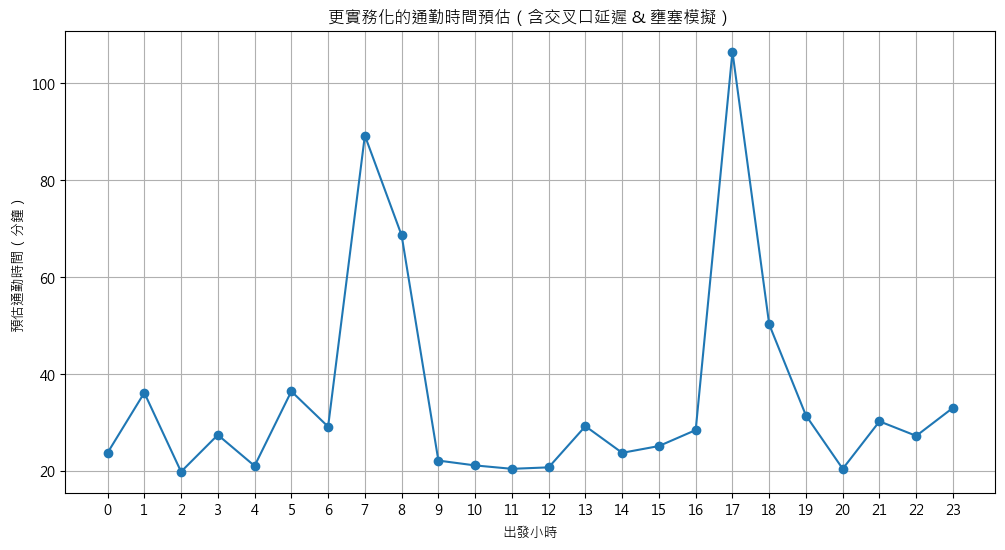

In [10]:
# 從 00:00～23:00，每小時出發一次
depart_hours = [f"2025-04-23 {str(h).zfill(2)}:00:00" for h in range(24)]
results = [estimate_realistic_travel_time(t, route, df)[0] for t in depart_hours]

# 視覺化
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(range(24), results, marker='o')
plt.xticks(range(24))
plt.xlabel("出發小時")
plt.ylabel("預估通勤時間（分鐘）")
plt.title("更實務化的通勤時間預估（含交叉口延遲 & 壅塞模擬）")
plt.grid(True)
plt.show()


In [13]:
import pandas as pd
from datetime import datetime, timedelta

# 起始時間
start_time = datetime(2025, 4, 23, 0, 0)
# 每隔 15 分鐘產生一個時間點
depart_times = [start_time + timedelta(minutes=15 * i) for i in range(96)]


In [14]:
travel_results = []

for t in depart_times:
    duration_min, arrive_time = estimate_realistic_travel_time(t, route, df)
    travel_results.append({
        "出發時間": t.strftime("%H:%M"),
        "預估行車時間 (分鐘)": duration_min,
        "預估到達時間": arrive_time.strftime("%H:%M")
    })

df_result = pd.DataFrame(travel_results)


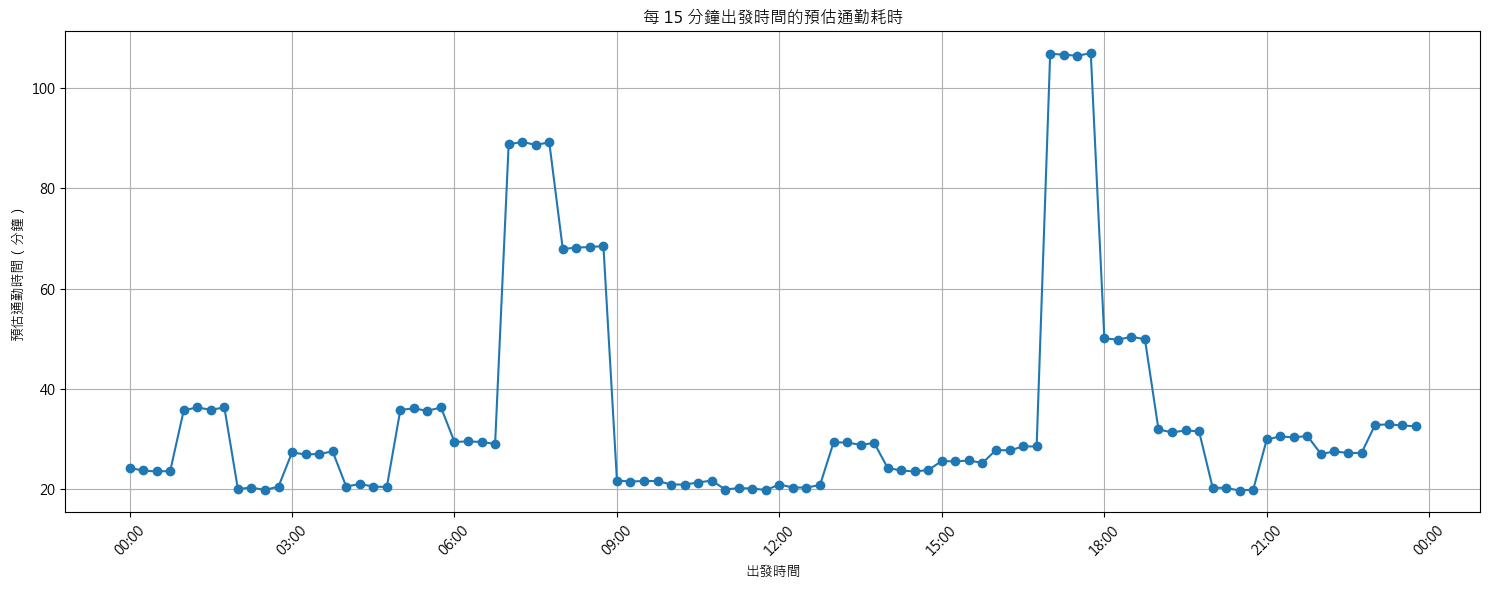

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 時間轉為 datetime 格式以利畫圖
df_result['出發時間_dt'] = pd.to_datetime("2025-04-23 " + df_result["出發時間"])

plt.figure(figsize=(15, 6))
plt.plot(df_result["出發時間_dt"], df_result["預估行車時間 (分鐘)"], marker='o', linestyle='-')
plt.title("每 15 分鐘出發時間的預估通勤耗時")
plt.xlabel("出發時間")
plt.ylabel("預估通勤時間（分鐘）")
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()


In [17]:
import openrouteservice

# 初始化 ORS client（填入你的 API 金鑰）
client = openrouteservice.Client(key='5b3ce3597851110001cf624833dd6c06156e46888a0ff84ee6e7df1c')

# 起訖點
start = (120.6598, 24.1073)
end = (120.5878, 24.1711)

# 取得 directions 資訊（包含指令）
route = client.directions(
    coordinates=[start, end],
    profile='driving-car',
    format='json',
    instructions=True
)

# 抓出所有導航指令
steps = route['routes'][0]['segments'][0]['steps']

# 印出行經道路與操作
for i, step in enumerate(steps):
    instruction = step.get('instruction')
    name = step.get('name')  # 路名
    distance = step.get('distance')
    print(f"{i+1:02d}. {instruction}（{name}）- 約 {int(distance)} 公尺")


01. Head west on 福田二街（福田二街）- 約 16 公尺
02. Turn right onto 文心南路901巷（文心南路901巷）- 約 246 公尺
03. Turn sharp left onto 文心南路（文心南路）- 約 1470 公尺
04. Turn left onto 建國北路一段（建國北路一段）- 約 1001 公尺
05. Turn right onto 環中路五段（環中路五段）- 約 642 公尺
06. Turn left onto 三民西路二段（三民西路二段）- 約 11 公尺
07. Turn right onto 環中路五段（環中路五段）- 約 3350 公尺
08. Turn left onto 向上路三段（向上路三段）- 約 4879 公尺
09. Turn right onto 五權西路三段, 136（五權西路三段, 136）- 約 8 公尺
10. Turn left onto 向上路五段, 136（向上路五段, 136）- 約 189 公尺
11. Turn right onto 工業區三十九路（工業區三十九路）- 約 441 公尺
12. Turn right onto 工業區三十九路（工業區三十九路）- 約 103 公尺
13. Turn left onto 工業區三十八路（工業區三十八路）- 約 32 公尺
14. Arrive at 工業區三十八路, on the left（-）- 約 0 公尺


In [18]:
# 安裝所需套件
!pip install openrouteservice folium

import openrouteservice
import folium
import pandas as pd

# ORS 初始化（請填入你的 API 金鑰）
client = openrouteservice.Client(key='5b3ce3597851110001cf624833dd6c06156e46888a0ff84ee6e7df1c')

# 起點與終點（福田水資源回收中心 → 台中工業區塑膠中心）
start = (120.6598, 24.1073)
end = (120.5878, 24.1711)

# 取得路徑（含導航指令）
route = client.directions(
    coordinates=[start, end],
    profile='driving-car',
    format='geojson',
    instructions=True
)

# 將導航步驟整理成表格
steps = route['features'][0]['properties']['segments'][0]['steps']
step_list = []
for i, step in enumerate(steps):
    step_list.append({
        "序號": i+1,
        "導航指令": step['instruction'],
        "道路名稱": step.get('name', ''),
        "距離（公尺）": int(step['distance'])
    })
df_steps = pd.DataFrame(step_list)
df_steps.to_csv("行經道路路線表.csv", index=False, encoding="utf-8-sig")

# 建立 folium 地圖
center = [(start[1]+end[1])/2, (start[0]+end[0])/2]
m = folium.Map(location=center, zoom_start=14)
folium.Marker(start[::-1], popup="起點", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(end[::-1], popup="終點", icon=folium.Icon(color="red")).add_to(m)

# 加入路線
folium.GeoJson(route, name="路徑").add_to(m)

# 匯出 HTML 地圖
m.save("通勤路線地圖.html")

# 顯示資料表
df_steps


,序號,導航指令,道路名稱,距離（公尺）
0,1,Head west on 福田二街,福田二街,16
1,2,Turn right onto 文心南路901巷,文心南路901巷,246
2,3,Turn sharp left onto 文心南路,文心南路,1470
3,4,Turn left onto 建國北路一段,建國北路一段,1001
4,5,Turn right onto 環中路五段,環中路五段,642
5,6,Turn left onto 三民西路二段,三民西路二段,11
6,7,Turn right onto 環中路五段,環中路五段,3350
7,8,Turn left onto 向上路三段,向上路三段,4879
8,9,"Turn right onto 五權西路三段, 136","五權西路三段, 136",8
9,10,"Turn left onto 向上路五段, 136","向上路五段, 136",189
